# Лабораторная работа №1
# Линейная регрессия и факторный анализ


## Цель работы

Изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качества.


## Постановка задачи

Провести обучение модели линейной регрессии на датасете с Kaggle.


В рамках выполнения лабораторной работы необходимо решить следующие задачи:

1. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).

2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной.

3. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).

4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности, выполнить расчет VIF-коэффициента.

5. Построить регрессионные модели:
   - линейную регрессию;
   - лассо-регрессию;
   - гребневую регрессию.

   Разделить данные на тренировочную и тестовую выборки (80/20 или 70/30), использовать кросс-валидацию и оценить качество моделей с помощью метрик:

   - RMSE (Root Mean Square Error);
   - R² (коэффициент детерминации);
   - MAPE (Mean Absolute Percentage Error).

6. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA).

   Перед проведением PCA выполнить стандартизацию данных.

7. Повторить построение моделей линейной, лассо- и гребневой регрессии, используя в качестве признаков главные компоненты вместо исходных данных.

   Выполнить сравнение метрик качества моделей, построенных на исходных данных и на главных компонентах.

## Выбор и описание датасета

В работе используется датасет Concrete Compressive Strength Dataset, содержащий информацию о составе бетонных смесей и их прочности на сжатие.

Данный набор данных предназначен для решения задачи регрессии, поскольку необходимо предсказать количественную характеристику — прочность бетона.

Каждая строка датасета представляет собой отдельный образец бетонной смеси. Для каждого образца представлены параметры состава смеси и возраст бетона, а также фактическое значение прочности.


В датасете представлены следующие переменные:

| Переменная | Описание |
|---|---|
| cement | количество цемента в бетонной смеси |
| blast_furnace_slag | количество доменного шлака |
| fly_ash | количество золы-уноса |
| water | количество воды |
| superplasticizer | количество суперпластификатора |
| coarse_aggregate | количество крупного заполнителя |
| fine_aggregate | количество мелкого заполнителя |
| age | возраст бетона в днях |
| concrete_compressive_strength | прочность бетона на сжатие |


Все признаки являются количественными переменными.

Независимые переменные (признаки X) — параметры состава бетонной смеси и возраст бетона:

- cement;
- blast_furnace_slag;
- fly_ash;
- water;
- superplasticizer;
- coarse_aggregate;
- fine_aggregate;
- age.


Зависимая переменная (целевая переменная y):

concrete_compressive_strength.

Именно значение этой переменной необходимо предсказать с помощью моделей машинного обучения.

Таким образом, задача работы заключается в построении регрессионной модели, которая устанавливает зависимость между характеристиками бетонной смеси и её прочностью.

In [150]:
# Импорт библиотек

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Библиотеки импортированы")

Библиотеки импортированы


In [151]:
# Загрузка датасета

df = pd.read_csv("data/concrete_data.csv")

df.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## Проверка загрузки данных

После загрузки датасета выполнен вывод первых строк таблицы.

Полученный результат подтверждает корректность чтения файла и показывает структуру исходных данных: названия признаков, их порядок расположения и первые значения наблюдений.

Каждая строка соответствует отдельному образцу бетонной смеси, а последний столбец concrete_compressive_strength является целевой переменной, которую необходимо предсказать.

## 1. Первичный анализ данных

## Первичный анализ данных

На данном этапе выполняется исследование структуры исходного набора данных. Проверяется размерность датасета, типы данных, наличие пропущенных значений, а также рассчитываются основные статистические характеристики признаков.

In [152]:
# Размер датасета

print("Размер датасета:")
print(df.shape)


# Информация о датасете

print("\nИнформация о датасете:")
df.info()


# Статистическое описание

print("\nСтатистическое описание:")
display(df.describe())


# Проверка пропущенных значений

print("\nПропущенные значения:")
display(df.isnull().sum())

Размер датасета:
(1030, 9)

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB

Статистическое описание:


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000



Пропущенные значения:


cement                           0
blast_furnace_slag               0
fly_ash                          0
water                            0
superplasticizer                 0
coarse_aggregate                 0
fine_aggregate                   0
age                              0
concrete_compressive_strength    0
dtype: int64

## Вывод по первичному анализу

В результате первичного анализа установлено, что датасет содержит 1030 наблюдений и 9 признаков.

Все признаки имеют числовой тип данных, поэтому дополнительное кодирование категориальных переменных не требуется.

Проверка пропущенных значений показала отсутствие пропусков в данных. Следовательно, дополнительная обработка отсутствующих значений перед обучением моделей не требуется.

Анализ статистических характеристик показал, что признаки имеют различные диапазоны значений, поэтому перед построением моделей машинного обучения необходимо выполнить стандартизацию данных.

Также установлено, что все признаки являются количественными переменными.

Это означает, что данные могут быть непосредственно использованы для построения регрессионных моделей без применения методов кодирования категориальных признаков.

Целевая переменная concrete_compressive_strength является непрерывной, поэтому задача относится к задачам регрессии.

## 2. Визуальный анализ данных

На данном этапе проводится графический анализ распределения признаков и целевой переменной. Это позволяет оценить характер распределения данных, выявить возможные выбросы и особенности отдельных факторов.

### 2.1 Распределение целевой переменной

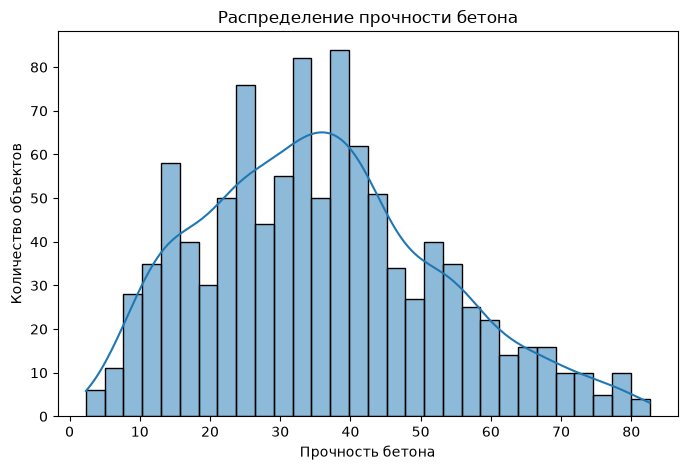

In [153]:
# Распределение целевой переменной

plt.figure(figsize=(8, 5))

sns.histplot(
    df["concrete_compressive_strength"],
    bins=30,
    kde=True
)

plt.title("Распределение прочности бетона")
plt.xlabel("Прочность бетона")
plt.ylabel("Количество объектов")

plt.show()

## Анализ распределения прочности бетона

На графике представлено распределение целевой переменной concrete_compressive_strength.

Можно наблюдать, что большая часть значений находится в диапазоне примерно 20–50 единиц прочности.

Также присутствуют образцы с низкой и высокой прочностью, что говорит о разнообразии исходных бетонных смесей.

Полученное распределение подтверждает, что целевая переменная является количественным непрерывным параметром и подходит для решения задачи регрессии.

### 2.2 Распределение входных признаков

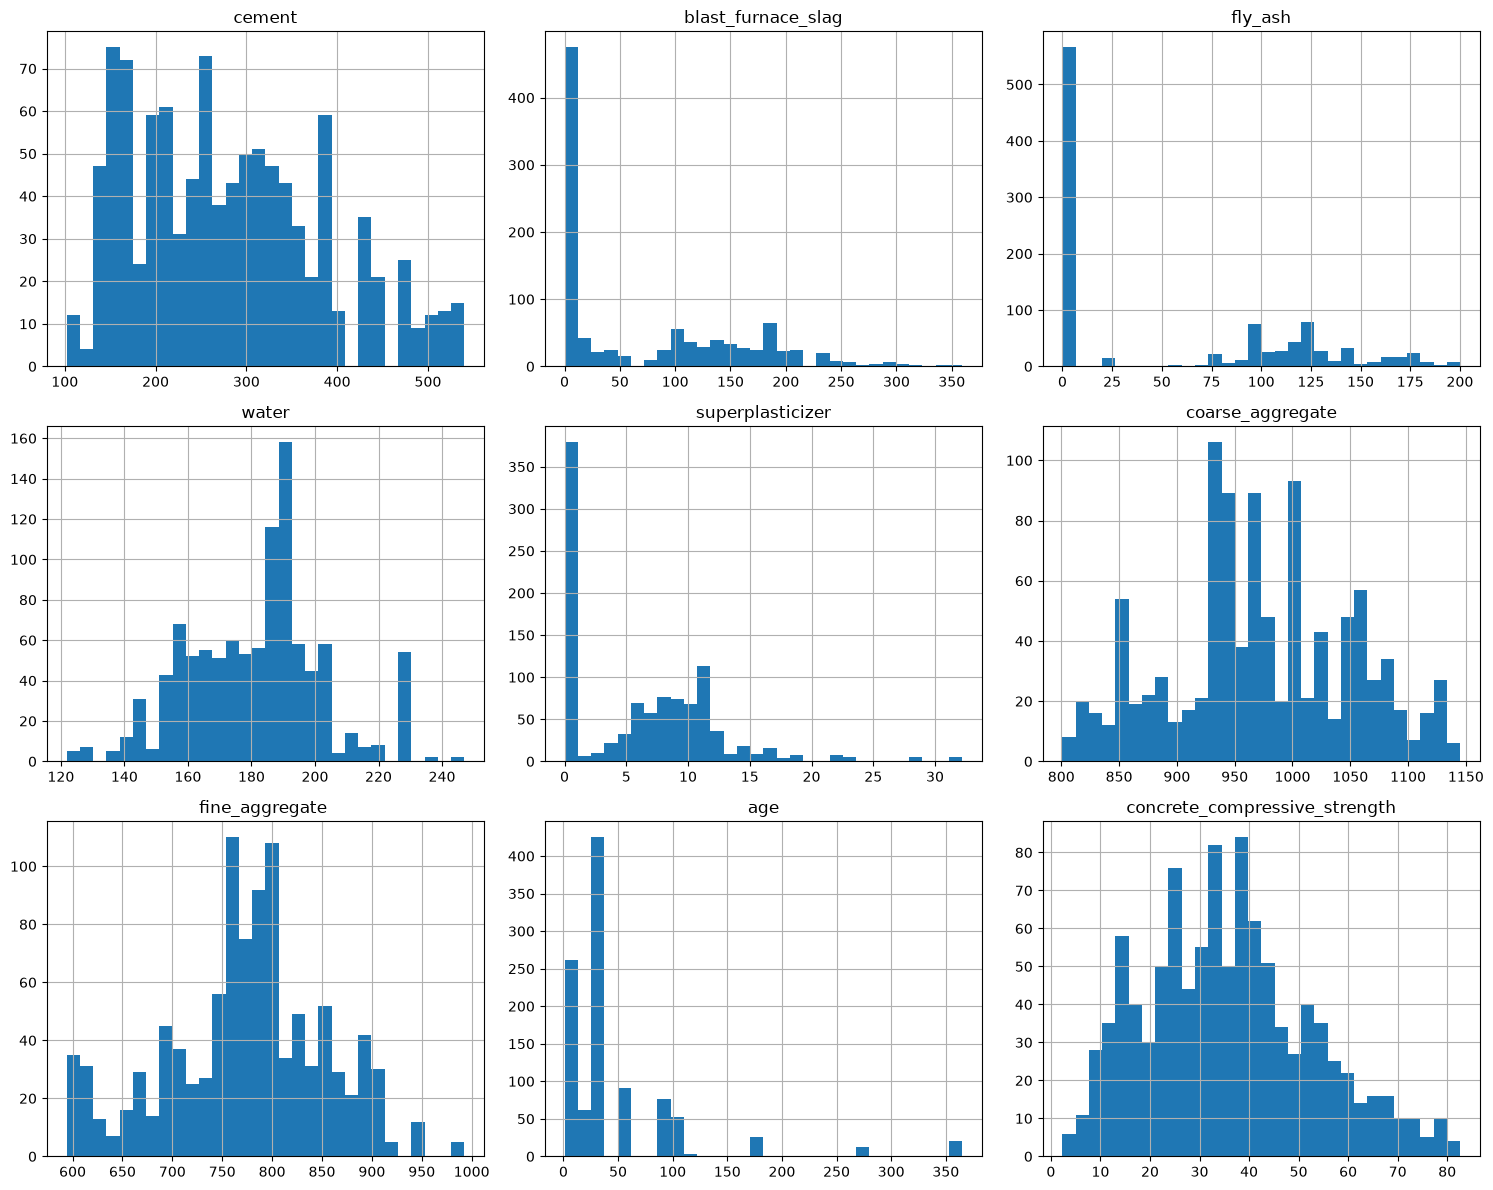

In [154]:
# Распределение входных признаков

df.hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

## Вывод по визуальному анализу

По результатам визуального анализа установлено, что признаки имеют различные диапазоны и формы распределения.

Целевая переменная concrete_compressive_strength имеет значения приблизительно от 2 до 82 единиц, при этом большая часть наблюдений находится в диапазоне средних значений прочности.

Некоторые признаки, например blast_furnace_slag, fly_ash и superplasticizer, имеют большое количество нулевых значений, что связано с особенностями состава бетонных смесей.

Полученные результаты подтверждают необходимость дальнейшего анализа взаимосвязей между признаками и подготовки данных перед обучением моделей.

## 3. Корреляционный анализ

Для оценки взаимосвязи между признаками была построена корреляционная матрица.

Коэффициент корреляции принимает значения от -1 до 1:
- значения, близкие к 1, показывают положительную зависимость;
- значения, близкие к -1, показывают отрицательную зависимость;
- значения около 0 свидетельствуют об отсутствии выраженной линейной связи.

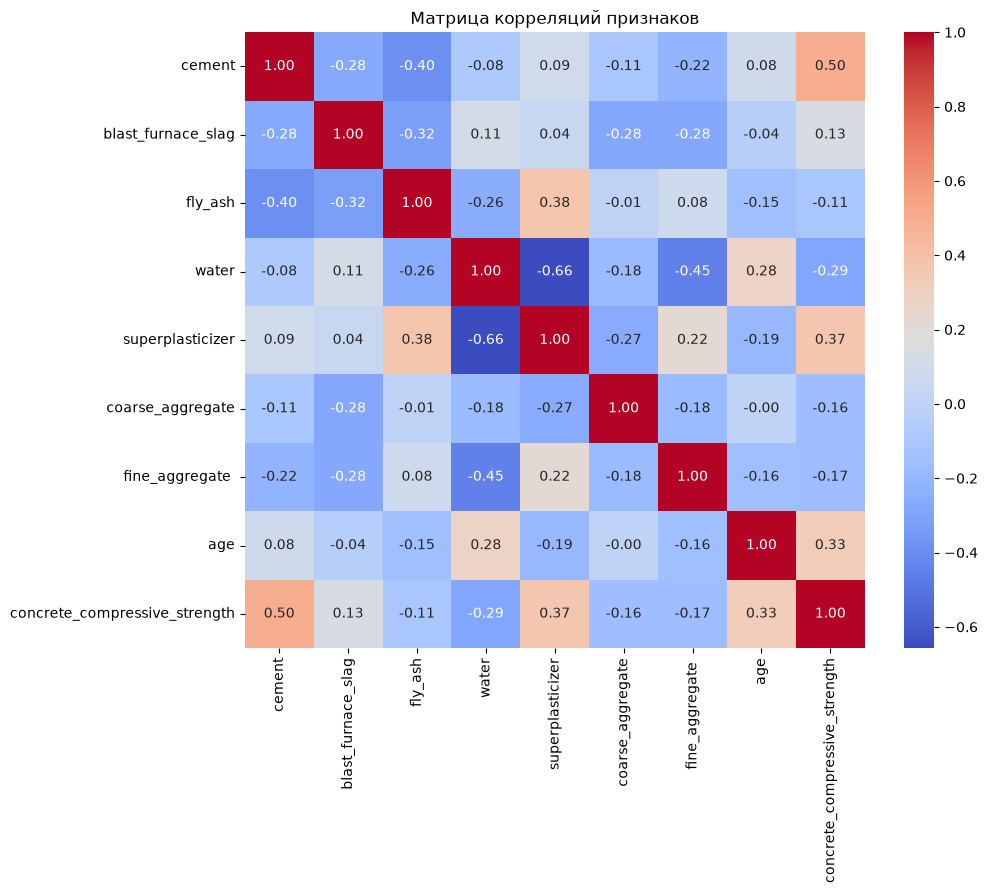

In [155]:
# Матрица корреляций

plt.figure(figsize=(10, 8))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Матрица корреляций признаков")

plt.show()

## Вывод по корреляционному анализу

Корреляционный анализ показал, что наиболее сильная положительная связь с прочностью бетона наблюдается у признака cement (коэффициент корреляции около 0.50).

Также положительное влияние имеют возраст бетона и количество суперпластификатора.

Отрицательная корреляция наблюдается между количеством воды и прочностью бетона, что соответствует особенностям формирования бетонной смеси.

При анализе взаимосвязей между независимыми признаками не обнаружены признаки с критически высокой корреляцией, однако отдельные факторы имеют умеренную взаимосвязь.

## 4. Проверка мультиколлинеарности (VIF)

In [156]:
# Расчет VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop("concrete_compressive_strength", axis=1)

vif_data = pd.DataFrame()

vif_data["feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data

,feature,VIF
0,cement,7.488944
1,blast_furnace_slag,7.276963
2,fly_ash,6.170634
3,water,7.003957
4,superplasticizer,2.963776
5,coarse_aggregate,5.074617
6,fine_aggregate,7.005081
7,age,1.118367


## Вывод по анализу мультиколлинеарности

Расчет VIF показал отсутствие сильной мультиколлинеарности между признаками, так как значения коэффициента не превышают критический порог 10, который обычно используется для выявления сильной мультиколлинеарности.

При этом некоторые признаки имеют повышенные значения VIF, например cement, blast_furnace_slag, water и fine_aggregate.

Это говорит о наличии умеренной взаимосвязи между отдельными компонентами бетонной смеси.

Для дополнительного снижения зависимости между признаками далее будет применен метод главных компонент PCA.

## 5. Подготовка данных

In [157]:
# 5.1 Разделение признаков и целевой переменной

X = df.drop("concrete_compressive_strength", axis=1)

y = df["concrete_compressive_strength"]

print("Размер признаков X:", X.shape)
print("Размер целевой переменной y:", y.shape)

Размер признаков X: (1030, 8)
Размер целевой переменной y: (1030,)


## Разделение признаков и целевой переменной

На данном этапе исходный набор данных разделяется на независимые переменные X и зависимую переменную y.

В качестве независимых переменных используются характеристики бетонной смеси и возраст образца.

Зависимой переменной является concrete_compressive_strength, которую необходимо предсказать с помощью моделей регрессии.

In [158]:
# 5.2 Разделение на train/test

from sklearn.model_selection import train_test_split

# Разделение данных на обучающую и тестовую выборки

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (824, 8)
Размер тестовой выборки: (206, 8)


## Разделение на обучающую и тестовую выборки

Данные были разделены в соотношении 80/20.

80% наблюдений используются для обучения моделей, а 20% — для проверки качества прогнозирования на ранее неиспользованных данных.

Такое разделение позволяет оценить способность модели работать с новыми объектами.

In [159]:
# 5.3 Стандартизация данных

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Стандартизация выполнена")

Стандартизация выполнена


## Стандартизация признаков

Так как исходные признаки имеют различные диапазоны значений, была выполнена стандартизация.

Метод StandardScaler преобразует признаки таким образом, чтобы они имели среднее значение 0 и стандартное отклонение 1.

Стандартизация особенно важна для моделей Ridge, Lasso и PCA, так как данные методы чувствительны к масштабу признаков.

## 6. Построение моделей регрессии

### 6.1 Линейная регрессия

In [160]:
from sklearn.linear_model import LinearRegression

# Создание модели

linear_model = LinearRegression()

# Обучение модели

linear_model.fit(X_train_scaled, y_train)

# Предсказание

y_pred_linear = linear_model.predict(X_test_scaled)

print("Линейная регрессия обучена")

Линейная регрессия обучена


## Обучение линейной регрессии

На данном этапе была построена базовая модель линейной регрессии.

Модель обучается на стандартизированных признаках обучающей выборки и устанавливает зависимость между параметрами бетонной смеси и прочностью бетона.

После обучения модель используется для прогнозирования значений целевой переменной на тестовой выборке.

### 6.2 Оценка качества линейной регрессии

In [161]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# Расчет метрик

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))

r2_linear = r2_score(y_test, y_pred_linear)

mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear) * 100


print("Linear Regression")
print("------------------")
print(f"RMSE: {rmse_linear:.2f}")
print(f"R²: {r2_linear:.3f}")
print(f"MAPE: {mape_linear:.2f}%")

Linear Regression
------------------
RMSE: 9.80
R²: 0.628
MAPE: 29.27%


## Интерпретация результатов Linear Regression

Полученное значение R² показывает, какую долю изменения прочности бетона объясняет модель.

Значение R² = 0.628 означает, что модель объясняет около 62.8% вариации целевой переменной.

RMSE показывает среднюю ошибку прогнозирования, а MAPE характеризует среднюю относительную ошибку модели.

### 6.3 Ridge Regression

In [162]:
from sklearn.linear_model import Ridge

# Создание модели Ridge

ridge_model = Ridge(alpha=1.0)

# Обучение

ridge_model.fit(X_train_scaled, y_train)

# Предсказание

y_pred_ridge = ridge_model.predict(X_test_scaled)

print("Ridge Regression обучена")

Ridge Regression обучена


## Обучение Ridge-регрессии

Ridge-регрессия является модификацией линейной регрессии, использующей L2-регуляризацию.

Добавление регуляризации позволяет уменьшить влияние больших коэффициентов модели и повысить устойчивость при наличии взаимосвязанных признаков.

In [163]:
# Оценка качества Ridge Regression

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

r2_ridge = r2_score(y_test, y_pred_ridge)

mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge) * 100


print("Ridge Regression")
print("----------------")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"R²: {r2_ridge:.3f}")
print(f"MAPE: {mape_ridge:.2f}%")

Ridge Regression
----------------
RMSE: 9.80
R²: 0.628
MAPE: 29.34%


## Интерпретация результатов Ridge Regression

Ridge-регрессия показала результаты, практически совпадающие с обычной линейной регрессией.

Полученные значения RMSE и R² свидетельствуют о том, что добавление L2-регуляризации не привело к существенному изменению качества модели.

Это связано с тем, что в исходных данных отсутствует сильная мультиколлинеарность, поэтому дополнительная регуляризация не оказала значительного влияния на модель.

### 6.4 Lasso Regression

In [164]:
from sklearn.linear_model import Lasso

# Создание модели Lasso

lasso_model = Lasso(alpha=1.0)

# Обучение

lasso_model.fit(X_train_scaled, y_train)

# Предсказание

y_pred_lasso = lasso_model.predict(X_test_scaled)

print("Lasso Regression обучена")

Lasso Regression обучена


## Обучение Lasso-регрессии

Lasso-регрессия использует L1-регуляризацию, которая позволяет уменьшать отдельные коэффициенты признаков вплоть до нулевых значений.

Таким образом модель может выполнять автоматический отбор менее значимых признаков.

In [165]:
# Оценка качества Lasso Regression

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

r2_lasso = r2_score(y_test, y_pred_lasso)

mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso) * 100


print("Lasso Regression")
print("----------------")
print(f"RMSE: {rmse_lasso:.2f}")
print(f"R²: {r2_lasso:.3f}")
print(f"MAPE: {mape_lasso:.2f}%")

Lasso Regression
----------------
RMSE: 10.60
R²: 0.564
MAPE: 35.86%


## Интерпретация результатов Lasso Regression

Lasso-регрессия показала более низкое качество по сравнению с Linear Regression и Ridge Regression.

Снижение качества связано с особенностью L1-регуляризации: модель уменьшает часть коэффициентов признаков до нулевых значений, выполняя отбор факторов.

В данном случае такое уменьшение количества используемых факторов привело к потере части информации, необходимой для точного прогнозирования прочности бетона.

### Сравнение моделей до PCA

In [166]:
# Сравнение моделей до PCA

results_before_pca = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "RMSE": [
        rmse_linear,
        rmse_ridge,
        rmse_lasso
    ],
    "R2": [
        r2_linear,
        r2_ridge,
        r2_lasso
    ],
    "MAPE (%)": [
        mape_linear,
        mape_ridge,
        mape_lasso
    ]
})

results_before_pca

,Model,RMSE,R2,MAPE (%)
0,Linear Regression,9.796476,0.627553,29.273485
1,Ridge Regression,9.796178,0.627576,29.338857
2,Lasso Regression,10.600404,0.563917,35.862315


## Анализ результатов моделей до PCA

На исходных признаках были построены три регрессионные модели: Linear Regression, Ridge Regression и Lasso Regression.

Линейная и Ridge-регрессия показали практически одинаковое качество. Значение коэффициента детерминации R² составило около 0.628, а RMSE — около 9.8.

Lasso-регрессия показала более низкое качество, что связано с особенностями L1-регуляризации, которая может уменьшать коэффициенты отдельных признаков до нуля и приводить к потере части информации.

Для проверки устойчивости результатов была выполнена 5-кратная кросс-валидация. Полученные результаты подтвердили стабильность линейной и Ridge-регрессии.

### 6.5 Кросс-валидация моделей

Для проверки устойчивости построенных моделей применяется метод k-fold кросс-валидации.

В данной работе используется 5-кратная кросс-валидация: исходная обучающая выборка разделяется на пять частей, после чего каждая часть по очереди используется для проверки модели, а остальные части — для обучения.

В качестве метрики оценки используется коэффициент детерминации R².

In [167]:
from sklearn.model_selection import cross_val_score

# Модели для кросс-валидации

models_cv = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model
}


# Расчет результатов кросс-валидации

cv_results = []

for name, model in models_cv.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="r2"
    )

    cv_results.append({
        "Model": name,
        "Mean R2 CV": scores.mean(),
        "Std R2 CV": scores.std()
    })


# Таблица результатов

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(3)

,Model,Mean R2 CV,Std R2 CV
0,Linear Regression,0.595,0.066
1,Ridge Regression,0.595,0.065
2,Lasso Regression,0.559,0.047


### Анализ результатов кросс-валидации

По результатам 5-кратной кросс-валидации были получены средние значения коэффициента детерминации R² для каждой модели.

Linear Regression и Ridge Regression показали практически одинаковые результаты, что говорит о стабильности моделей и отсутствии существенного влияния регуляризации Ridge при выбранном параметре.

Lasso Regression продемонстрировала несколько меньшее значение среднего R², что соответствует результатам оценки модели на тестовой выборке.

Полученные результаты подтверждают, что наиболее устойчивыми моделями для данного набора данных являются Linear Regression и Ridge Regression.

## 7. Снижение размерности методом PCA

### 7.1 Применение метода главных компонент

In [168]:
from sklearn.decomposition import PCA

# Создание PCA со всеми компонентами

pca = PCA()

# Обучение PCA на обучающих данных

X_train_pca = pca.fit_transform(X_train_scaled)

# Преобразование тестовых данных

X_test_pca = pca.transform(X_test_scaled)

print("Количество компонент:", pca.n_components_)

Количество компонент: 8


## Получение главных компонент

На данном этапе выполняется преобразование исходных стандартизированных признаков в новое пространство главных компонент.

Сначала PCA применяется со всеми компонентами для анализа вклада каждой компоненты и определения оптимального количества признаков для дальнейшего обучения моделей.

После оценки объясненной дисперсии будет выбрано количество компонент, позволяющее сохранить основную часть информации исходных данных.

In [169]:
# 7.2 Доля объясненной дисперсии каждой компоненты

explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.28019088, 0.17909394, 0.16827629, 0.12802619, 0.11811602,
       0.09938551, 0.02303032, 0.00388084])

## Анализ вклада главных компонент

Полученные значения показывают долю информации, которую сохраняет каждая главная компонента.

Для выбора количества компонент используется накопленная объясненная дисперсия.

Необходимо выбрать такое количество компонент, которое сохранит большую часть информации исходных данных при уменьшении размерности.

In [170]:
# Накопленная объясненная дисперсия

cumulative_variance = explained_variance.cumsum()

cumulative_variance

array([0.28019088, 0.45928482, 0.62756111, 0.7555873 , 0.87370332,
       0.97308883, 0.99611916, 1.        ])

## Накопленная объясненная дисперсия

Накопленная объясненная дисперсия показывает, какая доля исходной информации сохраняется при использовании определенного количества главных компонент.

На основе полученных значений определяется оптимальное количество компонент, которое позволяет уменьшить размерность данных без значительной потери информации.

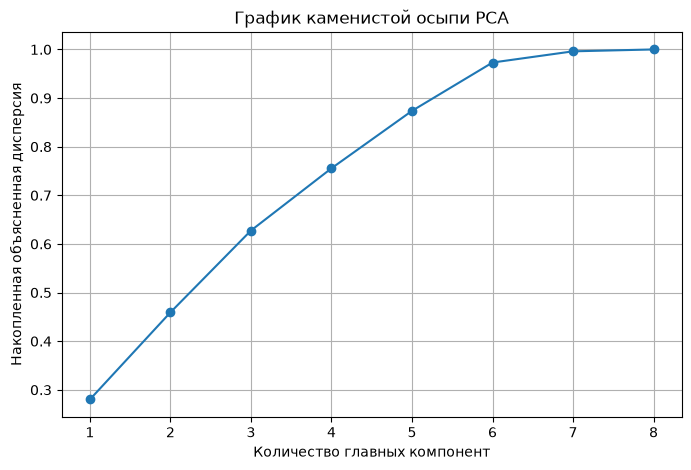

In [171]:
# График каменистой осыпи PCA

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Количество главных компонент")
plt.ylabel("Накопленная объясненная дисперсия")

plt.title("График каменистой осыпи PCA")

plt.grid()

plt.show()

## Вывод по PCA

На основании анализа накопленной объясненной дисперсии было выбрано 5 главных компонент.

Первые пять компонент сохраняют 87.4% общей дисперсии исходных данных, что соответствует рекомендуемому уровню сохранения информации 80–90%.

Таким образом, использование пяти главных компонент позволяет существенно уменьшить размерность признакового пространства:

- количество исходных признаков: 8;
- количество компонент после PCA: 5.

Снижение размерности составило 37.5%, при этом была сохранена основная часть информации исходных данных.

Выбранное количество компонент используется далее для повторного построения регрессионных моделей и сравнения их качества с моделями, построенными на исходных признаках.

### 7.3 Преобразование данных с использованием выбранного количества компонент

In [172]:
# PCA с выбранным количеством компонент

pca_5 = PCA(n_components=5)

X_train_pca = pca_5.fit_transform(X_train_scaled)

X_test_pca = pca_5.transform(X_test_scaled)

print("Размер обучающей выборки после PCA:", X_train_pca.shape)
print("Размер тестовой выборки после PCA:", X_test_pca.shape)

Размер обучающей выборки после PCA: (824, 5)
Размер тестовой выборки после PCA: (206, 5)


## 8. Построение моделей после PCA

In [173]:
from sklearn.linear_model import LinearRegression

# Линейная регрессия на PCA-признаках

linear_pca = LinearRegression()

linear_pca.fit(X_train_pca, y_train)

y_pred_linear_pca = linear_pca.predict(X_test_pca)

print("Linear Regression PCA обучена")

Linear Regression PCA обучена


## Обучение Linear Regression на PCA-признаках

После преобразования данных методом PCA модель линейной регрессии обучается уже не на исходных признаках, а на пяти главных компонентах.

Это позволяет оценить влияние снижения размерности на качество прогнозирования.

In [174]:
# Метрики Linear Regression PCA

rmse_linear_pca = np.sqrt(
    mean_squared_error(y_test, y_pred_linear_pca)
)

r2_linear_pca = r2_score(
    y_test, y_pred_linear_pca
)

mape_linear_pca = (
    mean_absolute_percentage_error(
        y_test,
        y_pred_linear_pca
    ) * 100
)


print("Linear Regression PCA")
print("---------------------")
print(f"RMSE: {rmse_linear_pca:.2f}")
print(f"R²: {r2_linear_pca:.3f}")
print(f"MAPE: {mape_linear_pca:.2f}%")

Linear Regression PCA
---------------------
RMSE: 11.58
R²: 0.480
MAPE: 37.58%


## Анализ Linear Regression после PCA

После преобразования признаков методом PCA качество модели снизилось.

Значение R² уменьшилось с 0.628 до 0.480.

Это говорит о том, что при уменьшении размерности была потеряна часть информации, которая была важна для прогнозирования прочности бетона.

### 8.2 Ridge Regression после PCA

In [175]:
from sklearn.linear_model import Ridge

# Ridge на PCA-признаках

ridge_pca = Ridge(alpha=1.0)

ridge_pca.fit(X_train_pca, y_train)

y_pred_ridge_pca = ridge_pca.predict(X_test_pca)

print("Ridge Regression PCA обучена")

Ridge Regression PCA обучена


## Обучение Ridge Regression после PCA

Ridge-регрессия обучается на новых признаках, полученных после PCA.

Так как главные компоненты являются ортогональными и не имеют линейной зависимости между собой, дополнительное применение регуляризации может не дать существенного улучшения качества.

In [176]:
# Метрики Ridge PCA

rmse_ridge_pca = np.sqrt(
    mean_squared_error(y_test, y_pred_ridge_pca)
)

r2_ridge_pca = r2_score(
    y_test,
    y_pred_ridge_pca
)

mape_ridge_pca = (
    mean_absolute_percentage_error(
        y_test,
        y_pred_ridge_pca
    ) * 100
)


print("Ridge Regression PCA")
print("--------------------")
print(f"RMSE: {rmse_ridge_pca:.2f}")
print(f"R²: {r2_ridge_pca:.3f}")
print(f"MAPE: {mape_ridge_pca:.2f}%")

Ridge Regression PCA
--------------------
RMSE: 11.58
R²: 0.480
MAPE: 37.59%


## Интерпретация Ridge Regression после PCA

После применения PCA Ridge-регрессия также показала снижение качества относительно модели, построенной на исходных признаках.

Так как PCA преобразует исходные признаки в новые компоненты, дополнительное применение Ridge-регуляризации не дало заметного улучшения качества.

### 8.3 Lasso Regression после PCA

In [177]:
from sklearn.linear_model import Lasso

# Lasso на PCA-признаках

lasso_pca = Lasso(alpha=1.0)

lasso_pca.fit(X_train_pca, y_train)

y_pred_lasso_pca = lasso_pca.predict(X_test_pca)

print("Lasso Regression PCA обучена")

Lasso Regression PCA обучена


## Обучение Lasso Regression после PCA

Lasso-регрессия применяется к преобразованным PCA-признакам для оценки влияния L1-регуляризации после снижения размерности.

Полученные результаты позволяют сравнить эффективность моделей до и после преобразования признакового пространства.

In [178]:
# Метрики Lasso PCA

rmse_lasso_pca = np.sqrt(
    mean_squared_error(y_test, y_pred_lasso_pca)
)

r2_lasso_pca = r2_score(
    y_test,
    y_pred_lasso_pca
)

mape_lasso_pca = (
    mean_absolute_percentage_error(
        y_test,
        y_pred_lasso_pca
    ) * 100
)


print("Lasso Regression PCA")
print("--------------------")
print(f"RMSE: {rmse_lasso_pca:.2f}")
print(f"R²: {r2_lasso_pca:.3f}")
print(f"MAPE: {mape_lasso_pca:.2f}%")

Lasso Regression PCA
--------------------
RMSE: 11.71
R²: 0.468
MAPE: 39.64%


## Интерпретация Lasso Regression после PCA

После применения PCA Lasso-регрессия показала наиболее низкое качество среди рассмотренных моделей.

Это связано с тем, что модель выполняет дополнительное уменьшение влияния признаков через L1-регуляризацию, что в сочетании с уже преобразованными PCA-признаками приводит к потере части информации.

### 8.4 Сравнение моделей до и после PCA

In [179]:
# Итоговое сравнение моделей до и после PCA

final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Linear Regression PCA",
        "Ridge Regression PCA",
        "Lasso Regression PCA"
    ],
    
    "RMSE": [
        rmse_linear,
        rmse_ridge,
        rmse_lasso,
        rmse_linear_pca,
        rmse_ridge_pca,
        rmse_lasso_pca
    ],
    
    "R2": [
        r2_linear,
        r2_ridge,
        r2_lasso,
        r2_linear_pca,
        r2_ridge_pca,
        r2_lasso_pca
    ],
    
    "MAPE (%)": [
        mape_linear,
        mape_ridge,
        mape_lasso,
        mape_linear_pca,
        mape_ridge_pca,
        mape_lasso_pca
    ]
})

final_results.round(3)

,Model,RMSE,R2,MAPE (%)
0,Linear Regression,9.796,0.628,29.273
1,Ridge Regression,9.796,0.628,29.339
2,Lasso Regression,10.600,0.564,35.862
3,Linear Regression PCA,11.580,0.480,37.576
4,Ridge Regression PCA,11.581,0.480,37.592
5,Lasso Regression PCA,11.707,0.468,39.640


## Анализ результатов после PCA

После применения PCA качество всех моделей снизилось по сравнению с моделями, построенными на исходных признаках.

Для линейной и Ridge-регрессии значение R² уменьшилось с 0.628 до 0.480.

Причиной снижения качества является потеря части информации при уменьшении размерности.

Метод PCA сохраняет направления максимальной дисперсии данных, однако эти направления не всегда являются наиболее информативными для прогнозирования целевой переменной.

Несмотря на снижение качества моделей, PCA успешно выполнил задачу снижения размерности и устранения линейной зависимости между признаками.

## 9. Сравнение качества моделей

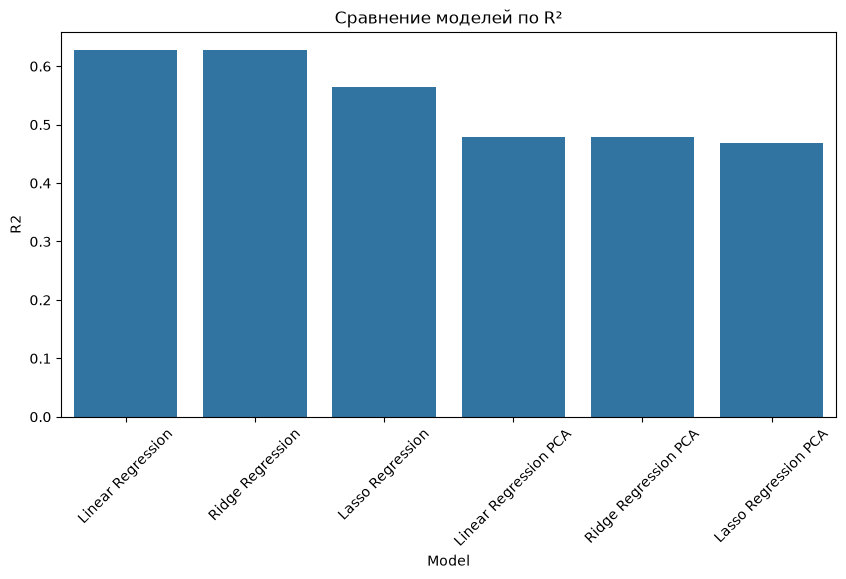

In [180]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=final_results,
    x="Model",
    y="R2"
)

plt.xticks(rotation=45)
plt.title("Сравнение моделей по R²")

plt.show()

## Анализ сравнения моделей по R²

График показывает, что модели, построенные на исходных признаках, имеют более высокие значения R² по сравнению с моделями после PCA.

Наилучшие результаты демонстрируют Linear Regression и Ridge Regression без снижения размерности.

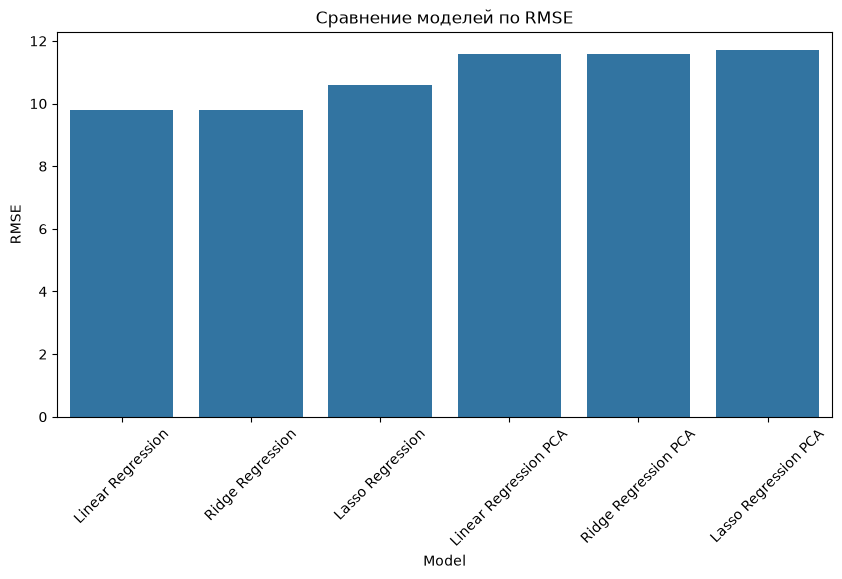

In [181]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=final_results,
    x="Model",
    y="RMSE"
)

plt.xticks(rotation=45)
plt.title("Сравнение моделей по RMSE")

plt.show()

## Анализ сравнения моделей по RMSE

По значению RMSE также видно, что модели без PCA имеют меньшую ошибку прогнозирования.

Следовательно, для данного набора данных применение PCA не позволило улучшить качество регрессии.

# Заключение

В ходе выполнения лабораторной работы были изучены основные этапы построения регрессионных моделей машинного обучения для прогнозирования прочности бетона.

В работе был выполнен первичный анализ исходного набора данных, включающий исследование структуры датасета, статистических характеристик, распределения признаков и целевой переменной.

Для изучения взаимосвязей между параметрами бетонной смеси была построена корреляционная матрица и выполнена оценка мультиколлинеарности с использованием VIF-коэффициента. По результатам анализа было установлено наличие умеренной взаимосвязи между отдельными признаками, при этом сильная мультиколлинеарность отсутствовала.

После подготовки данных были построены модели Linear Regression, Ridge Regression и Lasso Regression. Наилучшие результаты показали Linear Regression и Ridge Regression, для которых коэффициент детерминации R² составил около 0.628, а значение RMSE — около 9.8.

Для проверки устойчивости моделей была выполнена 5-кратная кросс-валидация. Полученные результаты подтвердили стабильность Linear Regression и Ridge Regression на выбранном наборе данных.

Также был исследован метод главных компонент PCA для снижения размерности признакового пространства. В результате было установлено, что первые пять главных компонент позволяют сохранить около 87.4% исходной информации при уменьшении количества признаков с 8 до 5.

После повторного обучения моделей на PCA-признаках качество прогнозирования снизилось. Это показывает, что для рассматриваемого набора данных исходные признаки содержали дополнительную информацию, которая была важна для предсказания прочности бетона.

Таким образом, в рамках лабораторной работы был выполнен полный цикл построения регрессионных моделей: подготовка и анализ данных, исследование взаимосвязей между признаками, обучение моделей, оценка качества, проверка устойчивости и применение метода снижения размерности PCA.